In [35]:
# ============================================================
# COACH — Session Start  (do not remove this cell)
# ============================================================
import sys, os
sys.path.insert(0, os.path.expanduser('~/Desktop/applied-ai-research'))
from coach.notebook_widgets import render_session_start
_SESSION = render_session_start(
    module_id="rnn",
    notebook_name="02_bptt.ipynb"
)

# Backpropagation Through Time (BPTT)

In the [previous notebook](./01_rnn_fundamentals.ipynb), you built a vanilla RNN and watched it process sequences step by step. The forward pass is clean. But how does an RNN **learn**?

This notebook answers that question by building BPTT from scratch. By the end you will:

1. Understand how gradients flow **backwards through time**
2. See **why** they vanish or explode
3. Implement **BPTT** with NumPy — computing exact gradients by hand
4. Observe gradient norms across time steps and witness the problem first-hand
5. Understand why this motivated the invention of LSTMs and GRUs

**The one-sentence summary**: An RNN learns by running its predictions forward through the sequence, measuring how wrong it was, and then walking *backward* through every step to adjust the weights. That backward walk is BPTT. The catch is that walking back 50 steps means multiplying 50 numbers together — and that product almost always becomes either zero (vanishing) or infinity (exploding).

---

## Jargon Buster

| Term | Plain English |
|------|---------------|
| **Backpropagation** | "Back-prop" — the algorithm for computing how much each weight contributed to the error, so we can fix it |
| **Gradient** | A number that tells you two things: (1) does this weight make the error go up or down? (2) by how much? |
| **Vanishing gradient** | When gradients get multiplied together so many times that they shrink to basically zero — early steps of the sequence stop learning |
| **Exploding gradient** | The opposite — gradients grow exponentially and cause the network to overshoot wildly |
| **BPTT** | Backpropagation Through Time — backprop applied to unrolled RNNs |
| **Unrolling** | Stretching the RNN into a chain, one copy per time step, to see how information (and gradients) flow |
| **Chain rule** | The math rule that lets us compute gradients through multiple layers. ∂L/∂w = (∂L/∂h) × (∂h/∂w) |
| **Gradient clipping** | A simple trick: if the gradient is too large, scale it down to a safe maximum. Prevents explosions |
| **Truncated BPTT** | A practical compromise: instead of backpropagating all the way to step 1, only go back k steps. Saves memory and time |
| **Spectral radius** | The largest eigenvalue of a matrix. If the spectral radius of W_hh is greater than 1, gradients tend to explode |

---


In [36]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(42)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def tanh(x):
    return np.tanh(x)

def tanh_deriv(x):
    return 1 - np.tanh(x) ** 2

print("Setup complete.")

Setup complete.


---

## Part 1: Unrolling the RNN

### The plain-English version first

Imagine you are reading a sentence one word at a time. After each word, you update your mental notes — your **hidden state**. Your brain at step 3 depends on your brain at step 2, which depends on step 1, and so on.

An RNN does the same thing. At each step it does two things:

1. **Updates its memory** — takes the current word + the previous memory and produces a new memory. We call this new memory `h_t` (h for "hidden state", t for "this time step").
2. **Makes a prediction** — uses the current memory to output an answer `y_t`.

That's it. Two lines of work per step.

### Now the equations (same idea, just written in math shorthand)

The first equation says: *new memory = tanh( input_weights × current_word + memory_weights × old_memory + bias )*

$$h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b)$$

- $x_t$ = the current word (or data point) at step t
- $h_{t-1}$ = the memory from the previous step
- $W_{xh}$ = the weights that decide how much the current word matters
- $W_{hh}$ = the weights that decide how much the old memory matters
- $b$ = a bias (like a starting nudge)
- $\tanh$ = a squishing function that keeps the values between -1 and 1

The second equation says: *prediction = output_weights × current_memory*

$$y_t = W_{hy} \cdot h_t$$

### Why "unrolling"?

Normally you picture the RNN as one box that loops. **Unrolling** means drawing T separate copies of that box in a row — one per time step — so you can see the whole computation laid out like a flowchart.

Why bother? Because to teach the RNN (backpropagation), you need to trace the error signal all the way from the end back to the beginning. Unrolling makes that path visible.

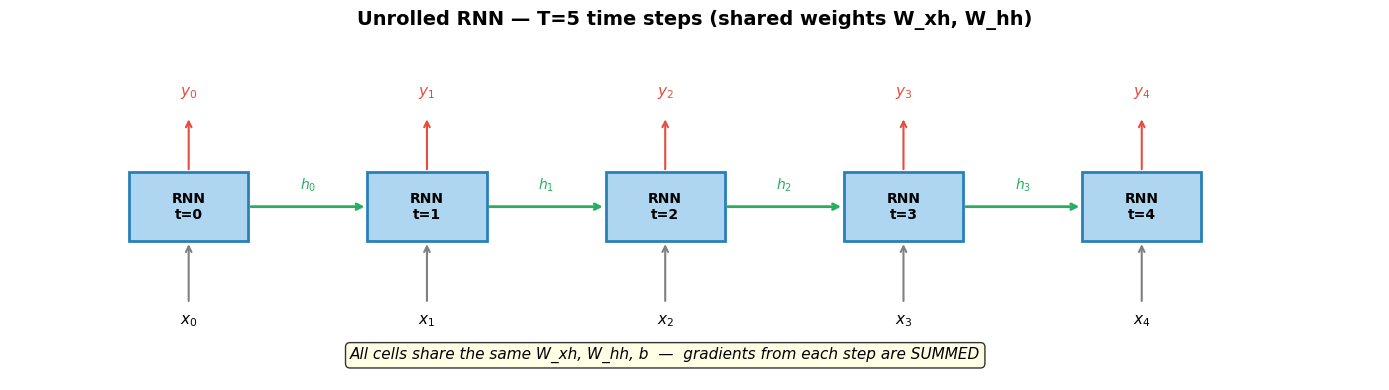

Forward pass: left to right.
Backward pass (BPTT): right to left, accumulating gradients at each step.


In [37]:
# Visualize unrolling

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(-0.5, 11)
ax.set_ylim(-1, 4)
ax.axis('off')
ax.set_title('Unrolled RNN — T=5 time steps (shared weights W_xh, W_hh)', fontsize=14, fontweight='bold')

T = 5
for t in range(T):
    x = 1 + t * 2
    # Cell box
    rect = plt.Rectangle((x - 0.5, 1.0), 1.0, 1.0,
                          facecolor='#AED6F1', edgecolor='#2980B9', linewidth=2)
    ax.add_patch(rect)
    ax.text(x, 1.5, f'RNN\nt={t}', ha='center', va='center', fontsize=10, fontweight='bold')
    # Input arrow
    ax.annotate('', xy=(x, 1.0), xytext=(x, 0.1),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))
    ax.text(x, -0.2, f'$x_{{{t}}}$', ha='center', fontsize=11)
    # Output arrow
    ax.annotate('', xy=(x, 2.8), xytext=(x, 2.0),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#E74C3C'))
    ax.text(x, 3.1, f'$y_{{{t}}}$', ha='center', fontsize=11, color='#E74C3C')
    # Hidden state arrow to next cell
    if t < T - 1:
        ax.annotate('', xy=(x + 1.5, 1.5), xytext=(x + 0.5, 1.5),
                    arrowprops=dict(arrowstyle='->', lw=2, color='#27AE60'))
        ax.text(x + 1.0, 1.75, f'$h_{{{t}}}$', ha='center', fontsize=10, color='#27AE60')

# Shared weights label
ax.text(5, -0.7, 'All cells share the same W_xh, W_hh, b  —  gradients from each step are SUMMED',
        ha='center', fontsize=11, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print("Forward pass: left to right.")
print("Backward pass (BPTT): right to left, accumulating gradients at each step.")

---

## Part 2: How the RNN Learns — BPTT Step by Step

### The big picture in one sentence

After the RNN makes predictions, it checks how wrong it was. Then it walks **backwards through time** — from the last step to the first — and nudges every weight slightly to make better predictions next time. That walk backwards is BPTT.

### Step 1: Measure total wrongness (the loss)

At every time step the RNN makes a prediction. Each prediction has some error. The total loss is just the sum of all those errors:

*Total loss = error at step 1 + error at step 2 + ... + error at step T*

$$L = \sum_{t=1}^{T} L_t$$

The big Σ (sigma) just means "add all of these up". Nothing scary.

### Step 2: Figure out how to improve the weights

The RNN has one key weight matrix called `W_hh` — it controls how memory flows from one step to the next. **Every single time step uses this same matrix.** That's what makes RNNs efficient, but also what makes training tricky.

Because every step uses the same `W_hh`, the total nudge we give it is the sum of nudges from every step:

*Total nudge for W_hh = nudge from step 1 + nudge from step 2 + ... + nudge from step T*

$$\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^{T} \frac{\partial L_t}{\partial W_{hh}}$$

The ∂ symbols just mean "how much does L change if we change W_hh a tiny bit". Same idea as above — just math notation for "nudge".

### Step 3: The chain reaction going backwards

Here is the hard part. To compute the nudge for step 1 from an error at step 40, the error signal has to travel **backwards through 39 steps**. At each step, it gets multiplied by two things:

1. The **tanh derivative** — a number between 0 and 1 (always shrinks the signal a little)
2. The **weight matrix W_hh** — can shrink or grow the signal depending on its size

So the total shrinkage from step 40 back to step 1 is:

*shrinkage = (tanh_deriv × W_hh) × (tanh_deriv × W_hh) × ... × (tanh_deriv × W_hh)*   ← 39 times

$$\frac{\partial h_t}{\partial h_k} = \prod_{j=k+1}^{t} \text{diag}(\tanh'(z_j)) \cdot W_{hh}$$

The big Π (pi) just means "multiply all of these together". Like 5! = 5×4×3×2×1 but with matrices.

**The problem:** If each multiplication shrinks the signal by even a little — say 0.9× — then after 39 multiplications you have 0.9³⁹ ≈ 0.01. The error signal at step 1 is basically zero. The network gets no useful feedback about what happened early in the sequence. This is the **vanishing gradient problem**.

In [38]:
class VanillaRNN:
    """
    Vanilla RNN with full BPTT.
    Forward pass stores all intermediate values needed for backprop.
    """
    def __init__(self, input_size, hidden_size, output_size):
        self.hidden_size = hidden_size
        scale = 0.1
        self.W_xh = np.random.randn(hidden_size, input_size) * scale
        self.W_hh = np.random.randn(hidden_size, hidden_size) * scale
        self.b_h  = np.zeros(hidden_size)
        self.W_hy = np.random.randn(output_size, hidden_size) * scale
        self.b_y  = np.zeros(output_size)

    def forward(self, X):
        """
        Forward pass over a sequence.
        X: (T, input_size)
        Returns outputs, hidden states, pre-activations (needed for BPTT).
        """
        T = X.shape[0]
        h = np.zeros(self.hidden_size)
        hs = [h.copy()]          # h_0 through h_T
        zs = []                  # pre-activation at each step
        ys = []                  # output at each step

        for t in range(T):
            z = self.W_xh @ X[t] + self.W_hh @ h + self.b_h
            h = tanh(z)
            y = self.W_hy @ h + self.b_y
            hs.append(h.copy())
            zs.append(z.copy())
            ys.append(y.copy())

        return np.array(ys), np.array(hs), np.array(zs)

    def bptt(self, X, dL_dy):
        """
        Full Backpropagation Through Time.
        X:      (T, input_size)
        dL_dy:  (T, output_size)  — gradient of loss w.r.t. each output y_t

        Returns gradient dict and per-step gradient norms for analysis.
        """
        T = X.shape[0]
        _, hs, zs = self.forward(X)

        # Accumulators
        dW_xh = np.zeros_like(self.W_xh)
        dW_hh = np.zeros_like(self.W_hh)
        db_h  = np.zeros_like(self.b_h)
        dW_hy = np.zeros_like(self.W_hy)
        db_y  = np.zeros_like(self.b_y)

        grad_norms = []   # track gradient norm at each step back

        for t in reversed(range(T)):
            # Gradient from output layer at step t
            dy = dL_dy[t]
            dW_hy += np.outer(dy, hs[t + 1])
            db_y  += dy
            dh = self.W_hy.T @ dy   # gradient of loss_t w.r.t. h_t

            # Backprop through time: go from step t back to step 0
            dh_next = dh.copy()
            step_norms = [np.linalg.norm(dh_next)]

            for k in reversed(range(t + 1)):
                # dh flows through tanh derivative
                dtanh = tanh_deriv(zs[k]) * dh_next
                # Accumulate weight gradients
                dW_xh += np.outer(dtanh, X[k])
                dW_hh += np.outer(dtanh, hs[k])   # hs[k] is h_{k-1} since hs is offset
                db_h  += dtanh
                # Backprop to previous hidden state
                dh_next = self.W_hh.T @ dtanh
                step_norms.append(np.linalg.norm(dh_next))

            grad_norms.append(step_norms)

        grads = dict(W_xh=dW_xh, W_hh=dW_hh, b_h=db_h, W_hy=dW_hy, b_y=db_y)
        return grads, grad_norms


print("VanillaRNN with BPTT defined.")
print("The bptt() method returns gradients + per-step gradient norms for analysis.")

VanillaRNN with BPTT defined.
The bptt() method returns gradients + per-step gradient norms for analysis.


---

## Part 3: Watch Gradients Vanish in Real Time

Let's run BPTT on a sequence and track how the gradient norm changes as we backpropagate further into the past.

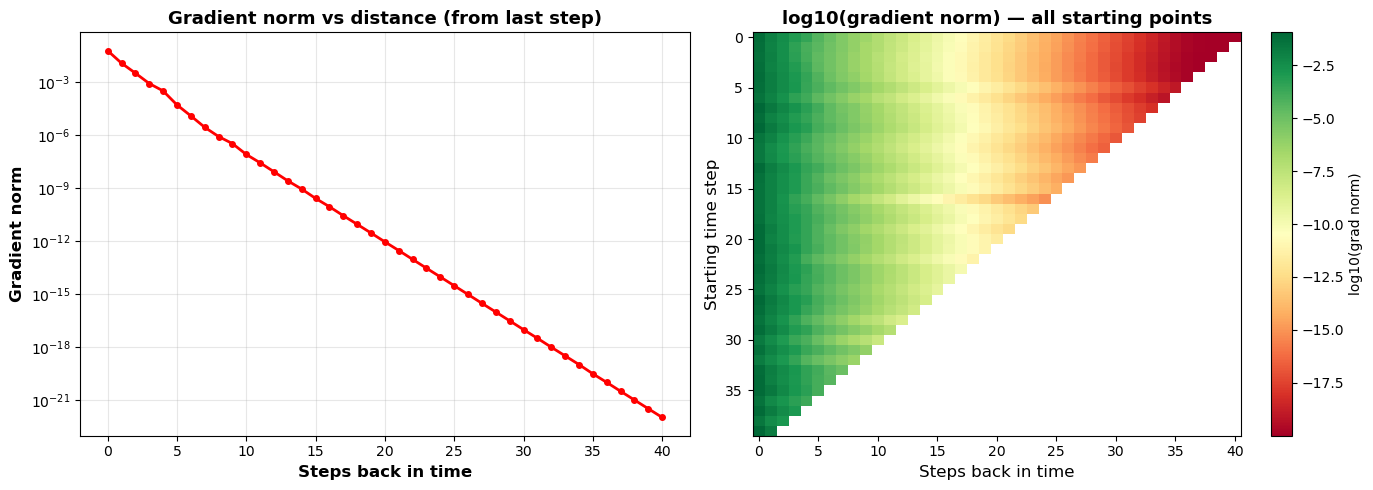

Gradient at step 0 (start of backprop): 0.0590
Gradient at step 20 (half-way back): 8.78e-13
Gradient at step 39 (all the way back): 1.00e-22

The gradient shrinks by a factor of ~10x every few steps.
By step 20+, it is essentially zero. The RNN cannot learn from signals that far back.


In [39]:
np.random.seed(42)

input_size  = 5
hidden_size = 10
output_size = 3
T = 40

rnn = VanillaRNN(input_size, hidden_size, output_size)

X = np.random.randn(T, input_size) * 0.5
# Simulate a gradient from the loss (e.g., MSE or cross-entropy)
dL_dy = np.random.randn(T, output_size) * 0.1

grads, grad_norms = rnn.bptt(X, dL_dy)

# Plot gradient norm vs steps back in time for the last time step
last_step_norms = grad_norms[0]  # grad_norms[0] = norms for t=T-1 (longest backprop path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: gradient norm from the last time step going back
axes[0].plot(last_step_norms, 'r-o', markersize=4, linewidth=2)
axes[0].set_xlabel('Steps back in time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Gradient norm', fontsize=12, fontweight='bold')
axes[0].set_title('Gradient norm vs distance (from last step)', fontsize=13, fontweight='bold')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Right: gradient norms from ALL time steps — heatmap
max_len = max(len(n) for n in grad_norms)
heat = np.full((len(grad_norms), max_len), np.nan)
for i, n in enumerate(grad_norms):
    heat[i, :len(n)] = n

im = axes[1].imshow(np.log10(heat + 1e-20), aspect='auto', cmap='RdYlGn')
axes[1].set_xlabel('Steps back in time', fontsize=12)
axes[1].set_ylabel('Starting time step', fontsize=12)
axes[1].set_title('log10(gradient norm) — all starting points', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=axes[1], label='log10(grad norm)')

plt.tight_layout()
plt.show()

print(f"Gradient at step 0 (start of backprop): {last_step_norms[0]:.4f}")
print(f"Gradient at step {T//2} (half-way back): {last_step_norms[T//2]:.2e}")
print(f"Gradient at step {T-1} (all the way back): {last_step_norms[-1]:.2e}")
print()
print("The gradient shrinks by a factor of ~10x every few steps.")
print("By step 20+, it is essentially zero. The RNN cannot learn from signals that far back.")

---

### What You Just Saw

Look at that plot on the left. The gradient norm starts at some small value when we backpropagate from the **last** time step, and by the time we are 20-30 steps into the past, it is basically **zero**.

Think of it like a telephone game (you might have played this as a kid): the teacher whispers a message to the first student, who whispers it to the next, and so on down a line of 40 students. Each time the message is passed along, it gets garbled a tiny bit. By student 40, the message is completely different.

In an RNN, the gradient is the "message." Every step backward in time is another student in the chain. The message is:

> "Hey weight W_hh — you made an error 30 steps ago. Here is how much you should change."

By the time that message travels 30 steps, it is so garbled (almost zero) that the weight barely updates at all. **The RNN cannot learn from things that happened far in the past.**

The heatmap on the right shows the same effect from every starting point. The dark green (high gradient) is always close to the diagonal. Far from the diagonal = almost zero. The RNN's "memory" effectively stops working after about 5-10 steps.

---

**Staff/Principal engineer level**: The gradient at time step $s$ with respect to the loss at time step $t > s$ is:

$$\frac{\partial L_t}{\partial h_s} = \frac{\partial L_t}{\partial h_t} \prod_{k=s+1}^{t} \frac{\partial h_k}{\partial h_{k-1}} = \frac{\partial L_t}{\partial h_t} \prod_{k=s+1}^{t} \text{diag}(\tanh'(z_k)) \cdot W_{hh}^\top$$

This is a product of $(t - s)$ matrices. If the spectral radius of $W_{hh}$ is less than 1, this product shrinks exponentially. If it is greater than 1, it grows exponentially (explosion). The only stable region is spectral radius exactly 1 — which is nearly impossible to maintain throughout training.


In [ ]:
# THE TELEPHONE GAME: Visualize gradient decay as a message getting garbled

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Plot 1: "Telephone game" analogy ---
# Show how a number gets shrunk each time it passes through a tanh derivative
# (which is between 0 and 1) and a small weight matrix

tanh_deriv_avg = 0.3     # typical average tanh'(z) value in a saturated network
w_spectral     = 0.9     # spectral radius of W_hh (well-initialized but slightly < 1)

steps = np.arange(0, 40)
signal_strength = (tanh_deriv_avg * w_spectral) ** steps

ax = axes[0]
ax.bar(steps, signal_strength, color='#3498DB', alpha=0.7, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Steps back in time', fontsize=12, fontweight='bold')
ax.set_ylabel('Signal strength (fraction of original)', fontsize=12, fontweight='bold')
ax.set_title('The Telephone Game: Signal Shrinks Each Step\n'
             f'(tanh derivative avg={tanh_deriv_avg}, W spectral radius={w_spectral})',
             fontsize=13, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Annotate key points
for step, label in [(5, 'Step 5'), (10, 'Step 10'), (20, 'Step 20'), (30, 'Step 30')]:
    strength = signal_strength[step]
    ax.annotate(f'{label}\n{strength:.1e}',
                xy=(step, strength), xytext=(step + 1, strength * 3),
                fontsize=9, color='#E74C3C', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.5))

# --- Plot 2: Compare different spectral radii ---
ax = axes[1]
spectral_radii = [0.7, 0.9, 0.95, 1.0, 1.05, 1.1]
colors = ['#1ABC9C', '#2980B9', '#8E44AD', '#F39C12', '#E74C3C', '#C0392B']

for sr, color in zip(spectral_radii, colors):
    signal = (tanh_deriv_avg * sr) ** steps
    ax.plot(steps, signal, '-', color=color, linewidth=2.5,
            label=f'Spectral radius = {sr}')

ax.axhline(y=1e-4, color='gray', linestyle='--', linewidth=1, alpha=0.5,
           label='Effectively zero (1e-4)')
ax.set_xlabel('Steps back in time', fontsize=12, fontweight='bold')
ax.set_ylabel('Signal strength (log scale)', fontsize=12, fontweight='bold')
ax.set_title('Effect of W_hh Spectral Radius on Gradient Flow\n'
             'Below 1.0 = vanishing, Above 1.0 = exploding!',
             fontsize=13, fontweight='bold')
ax.set_yscale('log')
ax.set_ylim(1e-20, 1e5)
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, alpha=0.3)

# Add shaded regions
ax.axhspan(1e-4, 1e5, xmin=0, xmax=0.5,
           alpha=0.05, color='blue', label='_nolegend_')
ax.text(5, 1e-12, 'Vanishing zone\n(spectral < 1/tanh_avg)',
        ha='center', fontsize=9, color='#2980B9', fontstyle='italic')
ax.text(25, 1e2, 'Exploding zone\n(spectral > 1/tanh_avg)',
        ha='center', fontsize=9, color='#E74C3C', fontstyle='italic')

plt.tight_layout()
plt.show()

print("KEY NUMBERS:")
print(f"  Starting signal strength: 1.0")
for step in [5, 10, 20, 30]:
    s = signal_strength[step]
    print(f"  After {step:2d} steps back: {s:.2e}  ({s*100:.4f}% of original)")

print()
print("This is why vanilla RNNs cannot learn from events more than ~10 steps ago.")
print("The gradient is ~zero by then -- no learning signal reaches those early steps.")


---

## Part 4: Why Does This Happen? The Explanation

### The multiplication problem

Imagine you are playing a game where you start with a score of 1000. Every round, your score gets multiplied by 0.8. After 30 rounds your score is:

1000 × 0.8³⁰ ≈ 1000 × 0.001 ≈ **1**

Almost nothing left. That is exactly what happens to the gradient signal in an RNN.

At every step backwards, the error signal gets multiplied by two things:
- **tanh derivative** — always between 0 and 1, so it always shrinks things
- **W_hh** — if this matrix tends to shrink vectors (small weights), the signal shrinks more

If the shrinking factor is below 1 on average, the signal disappears. If it is above 1 on average, it explodes.

### What "spectral radius" means in plain English

The **spectral radius** of W_hh is just a single number that answers the question: *"on average, does this matrix make vectors bigger or smaller?"*

- spectral radius < 1 → the matrix shrinks vectors → gradient **vanishes**
- spectral radius > 1 → the matrix grows vectors → gradient **explodes**
- spectral radius = 1 → the matrix keeps vectors the same size → gradient stays stable

Think of it like a photocopier. A 90% zoom copier (spectral radius = 0.9) makes every copy slightly smaller than the last. After 30 copies the text is unreadable. A 110% zoom copier (spectral radius = 1.1) makes every copy slightly bigger. After 30 copies the text is way off the page.

### The equation (just translating the words above into symbols)

$$\prod_{j=k+1}^{t} \text{diag}(1 - \tanh^2(z_j)) \cdot W_{hh}$$

- $\prod$ means multiply everything together (like the repeated photocopying)
- $1 - \tanh^2(z_j)$ is the tanh derivative — always between 0 and 1
- $W_{hh}$ is the weight matrix — each copy multiplied by this too

If this product ends up tiny after many multiplications → vanishing gradient.

WHY GRADIENTS VANISH: The Eigenvalue Explanation


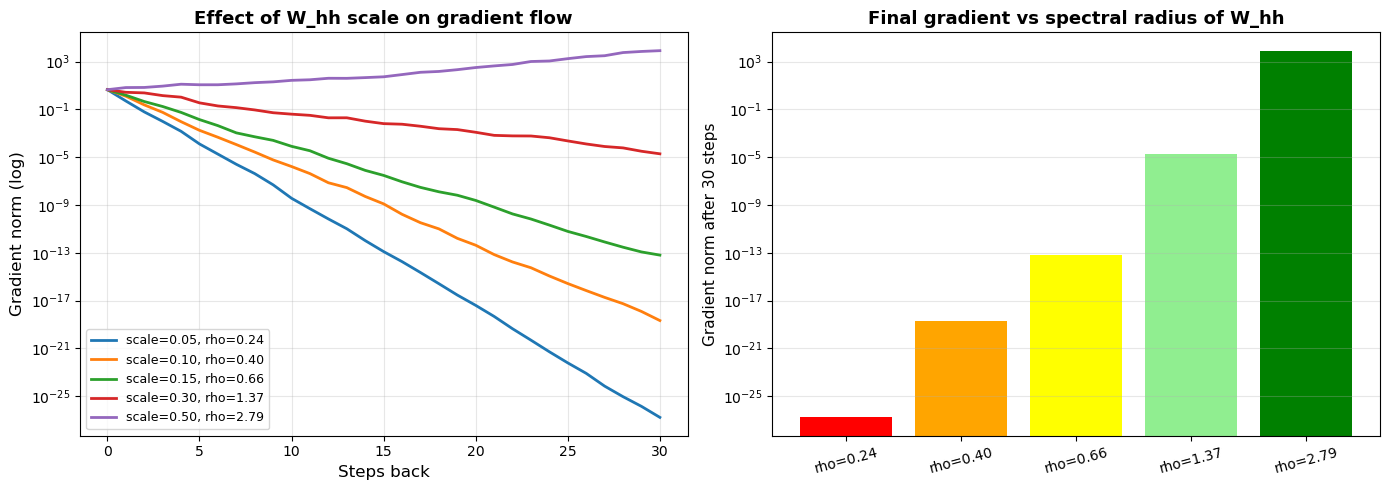


Key insight:
  spectral_radius(W_hh) < 1  =>  gradients VANISH
  spectral_radius(W_hh) > 1  =>  gradients EXPLODE
  spectral_radius(W_hh) = 1  =>  gradients stay stable (rare in practice)

This is the fundamental tension: the same W_hh must be good at
the forward pass AND must keep gradients alive in the backward pass.


In [40]:
# Demonstrate the mathematical cause

print("WHY GRADIENTS VANISH: The Eigenvalue Explanation")
print("=" * 60)

np.random.seed(0)
sizes   = [10, 20, 50]
scales  = [0.05, 0.1, 0.15, 0.3, 0.5]
T_steps = 30

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hidden_size_demo = 20
results = {}

for scale in scales:
    W = np.random.randn(hidden_size_demo, hidden_size_demo) * scale
    spectral_radius = max(abs(np.linalg.eigvals(W)))

    grad = np.ones(hidden_size_demo)
    norms = [np.linalg.norm(grad)]
    for _ in range(T_steps):
        tanh_d = np.random.uniform(0.1, 0.9, hidden_size_demo)  # typical tanh derivatives
        grad = (tanh_d * grad) @ W
        norms.append(np.linalg.norm(grad))

    results[scale] = (spectral_radius, norms)
    axes[0].plot(norms, label=f'scale={scale:.2f}, rho={spectral_radius:.2f}', linewidth=2)

axes[0].set_yscale('log')
axes[0].set_xlabel('Steps back', fontsize=12)
axes[0].set_ylabel('Gradient norm (log)', fontsize=12)
axes[0].set_title('Effect of W_hh scale on gradient flow', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: spectral radius vs final gradient norm
radii = [results[s][0] for s in scales]
final_norms = [results[s][1][-1] for s in scales]
axes[1].bar(range(len(scales)), final_norms, color=['red','orange','yellow','lightgreen','green'])
axes[1].set_xticks(range(len(scales)))
axes[1].set_xticklabels([f'rho={r:.2f}' for r in radii], rotation=15)
axes[1].set_ylabel(f'Gradient norm after {T_steps} steps', fontsize=11)
axes[1].set_title('Final gradient vs spectral radius of W_hh', fontsize=13, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("Key insight:")
print("  spectral_radius(W_hh) < 1  =>  gradients VANISH")
print("  spectral_radius(W_hh) > 1  =>  gradients EXPLODE")
print("  spectral_radius(W_hh) = 1  =>  gradients stay stable (rare in practice)")
print()
print("This is the fundamental tension: the same W_hh must be good at")
print("the forward pass AND must keep gradients alive in the backward pass.")

---

## Part 5: Gradient Clipping — The Quick Fix for Explosion

Before LSTMs, practitioners dealt with the explosion half of the problem with a simple trick: **gradient clipping**. If the gradient norm exceeds a threshold, scale it down so the norm equals the threshold.

This prevents numerical instability but does **not** solve the vanishing problem.

In [41]:
def clip_gradients(grads, max_norm=5.0):
    """Scale all gradients if total norm exceeds max_norm."""
    total_norm = np.sqrt(sum(np.sum(g**2) for g in grads.values()))
    if total_norm > max_norm:
        scale = max_norm / total_norm
        return {k: v * scale for k, v in grads.items()}, total_norm
    return grads, total_norm


# Demo: simulate exploding gradients then clip
np.random.seed(1)
rnn_explode = VanillaRNN(input_size=3, hidden_size=15, output_size=2)
# Make W_hh have large spectral radius to cause explosion
rnn_explode.W_hh = np.random.randn(15, 15) * 0.8

X_demo  = np.random.randn(20, 3)
dL_demo = np.random.randn(20, 2) * 2.0  # large upstream gradient

grads_raw, _  = rnn_explode.bptt(X_demo, dL_demo)
grads_clip, raw_norm = clip_gradients(grads_raw, max_norm=5.0)

raw_total  = np.sqrt(sum(np.sum(g**2) for g in grads_raw.values()))
clip_total = np.sqrt(sum(np.sum(g**2) for g in grads_clip.values()))

print("Gradient Clipping Demo")
print("-" * 40)
print(f"Raw gradient norm:     {raw_total:.2f}")
print(f"Clipped gradient norm: {clip_total:.2f}  (max_norm=5.0)")
print()
print("Clipping prevents explosion but gradients for EARLY time steps")
print("are still near zero — the vanishing problem remains.")
print()
print("The real solution: LSTM (notebook 03) or GRU (notebook 04).")
print("They give gradients a shortcut path that bypasses repeated tanh application.")

Gradient Clipping Demo
----------------------------------------
Raw gradient norm:     3725.29
Clipped gradient norm: 5.00  (max_norm=5.0)

Clipping prevents explosion but gradients for EARLY time steps
are still near zero — the vanishing problem remains.

The real solution: LSTM (notebook 03) or GRU (notebook 04).
They give gradients a shortcut path that bypasses repeated tanh application.


---

## Part 6: Truncated BPTT

Full BPTT over T=1000 steps is expensive: it requires storing all T hidden states and doing T backward passes. **Truncated BPTT** is the practical compromise:

1. Run the forward pass for k steps, keeping track of hidden states
2. Backpropagate only k steps back (not all the way to the beginning)
3. Advance k steps forward and repeat

The hidden state carries information from earlier steps even though the gradients don't reach that far. In practice k=20-50 is common.

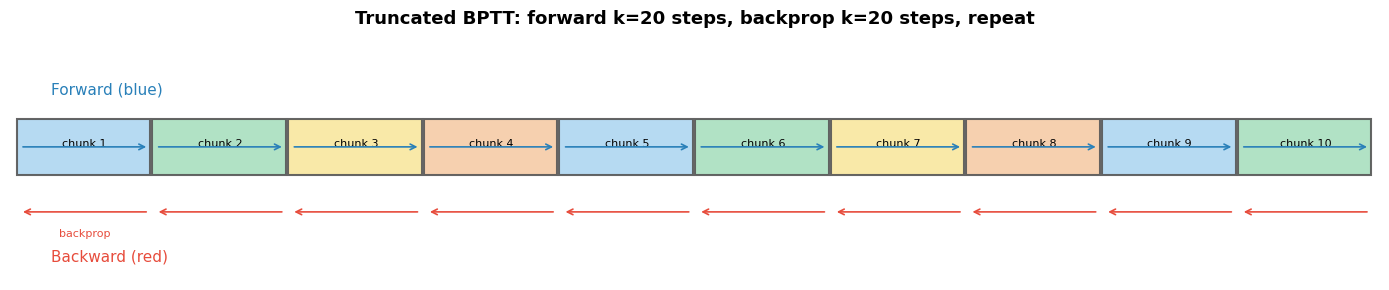

Full BPTT over T=200: need to store 200 hidden states, do 200 backward passes
Truncated BPTT k=20: store only 20 hidden states per chunk, do 20 backward passes per chunk
Memory saving: 10x

Tradeoff: gradients can't flow past the chunk boundary.
Dependencies longer than k steps won't be learned.


In [42]:
# Illustrate truncated BPTT

T_long = 200
k = 20  # truncation length

fig, ax = plt.subplots(figsize=(14, 3))
ax.set_xlim(-1, T_long + 1)
ax.set_ylim(-1.5, 2.5)
ax.axis('off')
ax.set_title(f'Truncated BPTT: forward k={k} steps, backprop k={k} steps, repeat',
             fontsize=13, fontweight='bold')

colors = ['#AED6F1', '#A9DFBF', '#F9E79F', '#F5CBA7']
n_chunks = T_long // k

for chunk in range(n_chunks):
    start = chunk * k
    color = colors[chunk % len(colors)]

    # Draw forward block
    rect = plt.Rectangle((start, 0.2), k - 0.3, 0.9,
                          facecolor=color, edgecolor='#555', linewidth=1.5, alpha=0.9)
    ax.add_patch(rect)
    ax.text(start + k/2, 0.65, f'chunk {chunk+1}', ha='center', fontsize=8)

    # Forward arrow
    ax.annotate('', xy=(start + k - 0.5, 0.65), xytext=(start + 0.5, 0.65),
                arrowprops=dict(arrowstyle='->', lw=1.2, color='#2980B9'))

    # Backward arrow (below)
    ax.annotate('', xy=(start + 0.5, -0.4), xytext=(start + k - 0.5, -0.4),
                arrowprops=dict(arrowstyle='->', lw=1.2, color='#E74C3C'))

    if chunk == 0:
        ax.text(start + k/2, -0.8, 'backprop', ha='center', fontsize=8, color='#E74C3C')

ax.annotate('Forward (blue)',  xy=(5, 1.5), fontsize=11, color='#2980B9')
ax.annotate('Backward (red)',  xy=(5, -1.2), fontsize=11, color='#E74C3C')

plt.tight_layout()
plt.show()

print(f"Full BPTT over T={T_long}: need to store {T_long} hidden states, do {T_long} backward passes")
print(f"Truncated BPTT k={k}: store only {k} hidden states per chunk, do {k} backward passes per chunk")
print(f"Memory saving: {T_long // k}x")
print()
print("Tradeoff: gradients can't flow past the chunk boundary.")
print("Dependencies longer than k steps won't be learned.")

---

## Part 7: Summary and the Road to LSTMs

| Problem | Cause | Fix |
|---------|-------|-----|
| Vanishing gradients | Product of small numbers shrinks exponentially | LSTM / GRU cell state highway |
| Exploding gradients | Spectral radius > 1 amplifies gradients | Gradient clipping |
| Memory cost of full BPTT | Must store all T hidden states | Truncated BPTT |

### Key Takeaways

1. BPTT is just standard backpropagation applied to the unrolled RNN graph
2. Because all time steps share `W_hh`, gradients are **summed** across all steps
3. The gradient from step $t$ to step $k$ is a **product** of $(t-k)$ Jacobians — it decays exponentially
4. Gradient clipping handles explosion; it does not solve vanishing
5. The real solution is changing the architecture so gradients have a low-resistance path — that is exactly what the LSTM cell state provides

**Next:** [03_lstm.ipynb](./03_lstm.ipynb) — build the LSTM from scratch and see the gradient highway in action.

---

## Test Your Understanding

1. **Why must BPTT sum gradients from all time steps, rather than computing separate gradient updates per step?**
   <details><summary>Answer</summary>
   All time steps use the same weight matrices (W_xh, W_hh, b). The gradient of the total loss with respect to a shared weight is the sum of the gradients from each time step's loss. Applying independent updates per step would violate the chain rule and produce incorrect gradients.
   </details>

2. **The spectral radius of W_hh is 0.8. What happens to gradients over 50 steps?**
   <details><summary>Answer</summary>
   They decay roughly as 0.8^50 ≈ 1.4e-5 — essentially zero. Any signal from the beginning of the sequence cannot influence the weights at all.
   </details>

3. **Why doesn't gradient clipping solve the vanishing gradient problem?**
   <details><summary>Answer</summary>
   Clipping scales DOWN large gradients to prevent explosion. But vanishing gradients are already near zero — there is nothing to clip. The problem requires a different architecture that gives gradients a path that doesn't shrink.
   </details>

4. **What is the memory cost of full BPTT for a sequence of length T and hidden size H?**
   <details><summary>Answer</summary>
   O(T * H) — you must store the hidden state at every time step to compute the backward pass.
   </details>

In [43]:
# ============================================================
# COACH — Session End  (do not remove this cell)
# ============================================================
from coach.notebook_widgets import render_session_end
render_session_end(_SESSION)